# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install Python
Anaconda3-5.2.0-Windows-x86_64.exe:

Python 3.6.5 |Anaconda, Inc.| (default, Mar 29 2018, 13:32:41) [MSC v.1900 64 bit (AMD64)]

Microsoft Visual Studio Professional 2017 Version 15.8.9

PTVS 15.8.18241.1-15.0

## Install PT3S to site-packages

In [1]:
### ggf. Rechte erforderlich:  Start-Process powershell -Verb runAs
###!pip uninstall --yes PT3S
###!pip install PT3S --no-cache-dir

## OR use local PT3S under Development

In [2]:
###!pip install -e .

## Logging

In [3]:
import logging
import os
logger = logging.getLogger('PT3S')  


logFileName= r"PT3S-Notebook.log"        
loglevel = logging.DEBUG
logging.basicConfig(filename=logFileName
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFileName)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

## about from PT3S ... import ... and pip install -e .

In [4]:
#%pwd

In [5]:
# works only if pip install -e .is NOT active:
###from PT3S import Mx,Xm,Rm
# or if subdir is PT3S
#%cd -q ..
# ...
#%cd -q PT3S 

In [6]:
# if pip install -e .IS active
# the local modules can be imported with:
import Mx, Xm, Rm
# if %pwd is local devdir

# ggf. Tests

In [7]:
%run test.py -q -m 0 -s "^Xm." -s "^Mx."

.
----------------------------------------------------------------------
Ran 1 test in 2.952s

OK
.
----------------------------------------------------------------------
Ran 1 test in 12.409s

OK
.
----------------------------------------------------------------------
Ran 1 test in 3.068s

OK


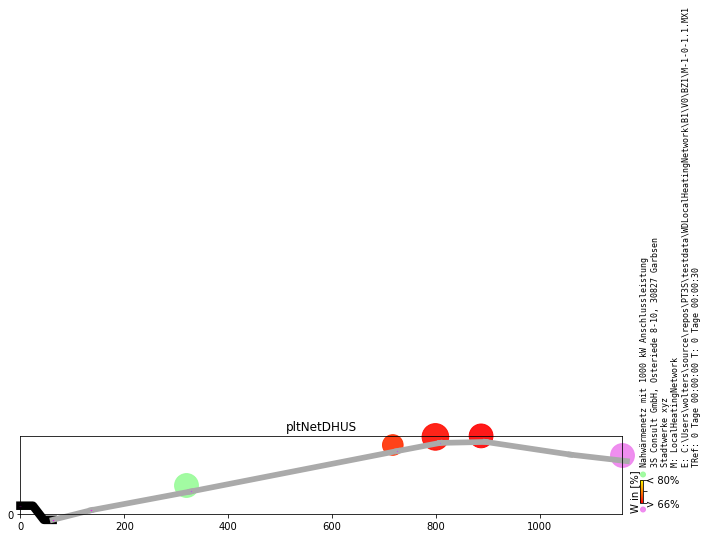

In [8]:
%run test.py -q

.
----------------------------------------------------------------------
Ran 1 test in 2.764s

OK
.
----------------------------------------------------------------------
Ran 1 test in 13.616s

OK
.
----------------------------------------------------------------------
Ran 1 test in 3.519s

OK


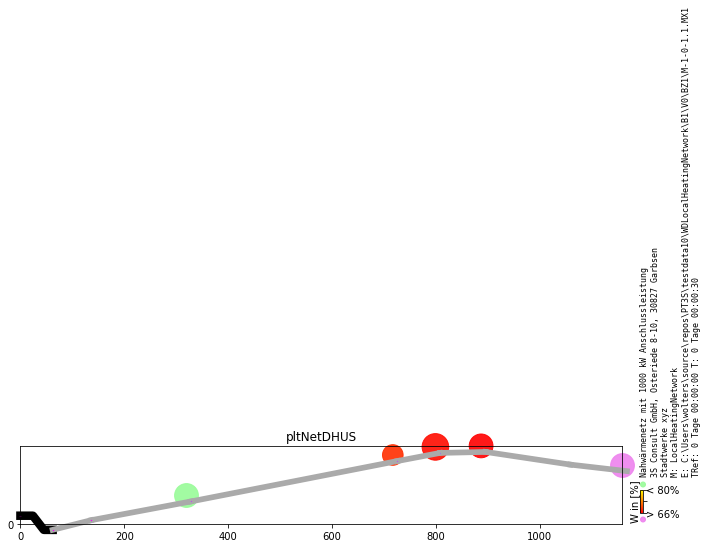

In [9]:
%run test.py -q --testDir testdata10 

.
----------------------------------------------------------------------
Ran 1 test in 2.834s

OK
.
----------------------------------------------------------------------
Ran 1 test in 14.001s

OK
.
----------------------------------------------------------------------
Ran 1 test in 3.180s

OK


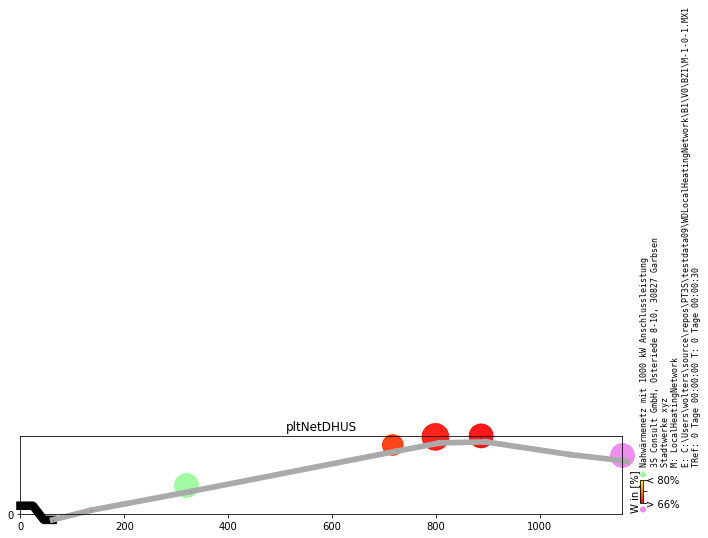

In [10]:
%run test.py -q --testDir testdata09 --dotResolution NONE

# Modell und Ergebnisse laden und nutzen

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import networkx as nx

## Modell

In [12]:
path='.'
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [13]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['BESCHREIBUNG','NAME_i','NAME_k','LAYR','L','D']).sort_index(level=1)

BESCHREIBUNG       NAME_i  NAME_k             LAYR       L      D
OBJTYPE OBJID                                                                                                  
ROHR    4613782368750024999                           None       R-K004  R-K005       [Rücklauf]   88.02  107.1
        4614949065966596185                           None       V-K002  V-K003        [Vorlauf]  405.96  107.1
        4637102239750163477                           None       R-K003  R-K004       [Rücklauf]   83.55  107.1
FWVB    4643800032883366034                              1       V-K002  R-K002  [Kundenanlagen]       0    NaN
VENT    4678923650983295610                           None          V-1     V-L        [Vorlauf]       0    150
FWVB    4704603947372595298                              3       V-K004  R-K004  [Kundenanlagen]       0    NaN
ROHR    4713733238627697042                           None       V-K004  V-K005        [Vorlauf]   88.02  107.1
        4769996343148550485                           None          R-L  R-K000       [Rücklauf]   73.42  160.3
        4789218195240364437                           None       V-K001  V-K002        [Vorlauf]  195.53  107.1
KLAP    4801110583764519435                           None           R2      R3       [Rücklauf]       0     80
VENT    4897018421024717974                           None          R-L     R-1       [Rücklauf]       0    150
ROHR    4939422678063487923                           None          V-L  V-K000        [Vorlauf]    68.6  160.3
        4945727430885351042                           None       R-K006  R-K007       [Rücklauf]  109.77  107.1
        4984202422877610920                           None       V-K000  V-K001        [Vorlauf]    76.4  107.1
PGRP    4986517622672493603                   Pumpengruppe          R-1      R3               []       0    NaN
ROHR    5037777106796980248                           None       V-K003  V-K004        [Vorlauf]   83.55  107.1
FWVB    5121101823283893406                              4       V-K005  R-K005  [Kundenanlagen]       0    NaN
ROHR    5123819811204259837                           None       V-K005  V-K006        [Vorlauf]  164.91  107.1
        5266224553324203132                           None       R-K001  R-K002       [Rücklauf]  195.53  107.1
        5379365049009065623                           None       R-K002  R-K003       [Rücklauf]  405.96  107.1
FWVB    5400405917816384862                              5       V-K007  R-K007  [Kundenanlagen]       0    NaN
PUMP    5481331875203087055                    Umwälzpumpe          R-1      R2       [Rücklauf]       0    NaN
VENT    5525310316015533093                           None  PKON-Knoten     R-1       [Rücklauf]       0     50
ROHR    5611703699850694889                           None       R-K005  R-K006       [Rücklauf]  164.91  107.1
        5620197984230756681                           None       V-K006  V-K007        [Vorlauf]  109.77  107.1
FWES    5638756766880678918  BHKW - Modul - 1000 kW therm.           R3     V-1        [Vorlauf]       0     80
ROHR    5647213228462830353                           None       R-K000  R-K001       [Rücklauf]    76.4  107.1
FWVB    5695730293103267172                              2       V-K003  R-K003  [Kundenanlagen]       0    NaN

In [14]:
vVBEL.dtypes

BESCHREIBUNG    object
IDREFERENZ      object
tk              object
NAME_i          object
CONT_i          object
CONT_VKNO_i     object
Z_i             object
pk_i            object
NAME_k          object
CONT_k          object
CONT_VKNO_k     object
Z_k             object
pk_k            object
LAYR            object
L               object
D               object
dtype: object

In [15]:
[viewOrTable for viewOrTable in sorted(xm.dataFrames.keys())]

['AGSN',
 'ALLG',
 'ALLG_BZ',
 'ARRW',
 'ATMO',
 'AVOS',
 'AVOS_ROWS',
 'BZAG',
 'BZAG_BZ',
 'CONT',
 'DATENEBENE',
 'DPGR',
 'DPGR_BZ',
 'DPGR_DPKT',
 'DPKT',
 'DRNP',
 'DTRO',
 'DTRO_ROWD',
 'EBES',
 'EBES_BZ',
 'ELEMENTQUERY',
 'ETAM',
 'ETAM_ROWS',
 'ETAR',
 'ETAR_ROWS',
 'ETAU',
 'ETAU_ROWS',
 'FSTF',
 'FWBZ',
 'FWES',
 'FWES_BZ',
 'FWVB',
 'FWVB_BZ',
 'GMIX',
 'GRAV',
 'GTXT',
 'KLAP',
 'KLAP_BZ',
 'KNOT',
 'KNOT_BZ',
 'LAYR',
 'LFAL',
 'LFAL_BZ',
 'LFKT',
 'LFKT_ROWT',
 'LTGR',
 'MAPG',
 'MAPG_ROWS',
 'MODELL',
 'NRCV',
 'PARI',
 'PARI_BZ',
 'PARV',
 'PARZ',
 'PARZ_BZ',
 'PGPR',
 'PGRP',
 'PGRP_BZ',
 'PGRP_PUMP',
 'PGRP_PUMP_BZ',
 'PHI1',
 'PHI1_ROWT',
 'PHI2',
 'PHI2_ROWS',
 'PHIV',
 'PHIV_ROWS',
 'PUMD',
 'PUMD_ROWT',
 'PUMK',
 'PUMK_ROWS',
 'PUMP',
 'PUMP_BZ',
 'PVAR',
 'PVAR_ROWT',
 'PZON',
 'PZVR',
 'PZVR_BZ',
 'QVAR',
 'QVAR_ROWT',
 'RART',
 'RART_BZ',
 'RCON',
 'RECT',
 'REGP',
 'ROHR',
 'ROHR_BZ',
 'RPFL',
 'RPLAN',
 'SIRGRAF',
 'SOKO',
 'SPLZ',
 'STOF',
 'STOF_ROWS',
 '

## Ergebnisse

In [16]:
# Weg A um an Ergebnisse zu kommen: 
# Modell(-Views) um MX-Ergebnisse ergaenzen; MX-Ergebnissatz des Modells wird implizit gelesen und returned
mx=xm.MxSync()

In [17]:
# Weg B um an Ergebnisse zu kommen:
# einen MX-Ergebnissatz voellig unabhaengig von einem Modell lesen
# z.B. den MX-Ergebnissatz des Modells ...
(wDir,modelDir,modelName,mx1File)=xm.getWDirModelDirModelName()  
# ... lesen
mx=Mx.Mx(mx1File=mx1File)

### Non-Vector

In [18]:
mx.df.filter(items=['ALLG~~~4639827058859487185~SNAPSHOTTYPE','KNOT~V-L~~5736262931552588702~PH'])

,ALLG~~~4639827058859487185~SNAPSHOTTYPE,KNOT~V-L~~5736262931552588702~PH
2004-09-22 08:30:00+00:00,b'STAT',4.125885
2004-09-22 08:30:15+00:00,b'TIME',3.161918
2004-09-22 08:30:30+00:00,b'TIME',2.597010
2004-09-22 08:30:45+00:00,b'TIME',2.207441
2004-09-22 08:31:00+00:00,b'TIME',4.225861


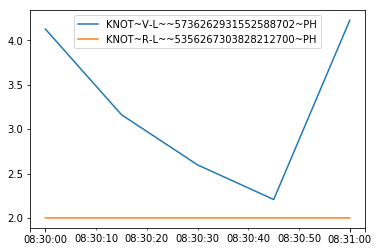

In [19]:
mx.df.filter(regex='^KNOT').filter(regex='PH$').plot()

### Vector

In [20]:
timesReq=mx.df.index.tolist()
mxVecsFileData=mx.getMxsVecsFileData(timesReq)
for vecsFileResult in mxVecsFileData:
    print(vecsFileResult.index)

DatetimeIndex(['2004-09-22 08:30:00+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:15+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:30+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:45+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:31:00+00:00'], dtype='datetime64[ns, UTC]', freq=None)


In [21]:
vecsFileResult.filter(regex='^ROHR').filter(regex='^(?!.*VEC)')

,ROHR~*~*~*~QMI,ROHR~*~*~*~VI,ROHR~*~*~*~VK,ROHR~*~*~*~QMK,ROHR~*~*~*~QMAV,ROHR~*~*~*~VAV,ROHR~*~*~*~IAKTIV
2004-09-22 08:31:00+00:00,"(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)"


In [22]:
vecsFileResult.filter(regex='^KNOT')

,KNOT~*~*~*~P,KNOT~*~*~*~HMAX_INST,KNOT~*~*~*~H,KNOT~*~*~*~T,KNOT~*~*~*~PDAMPF,KNOT~*~*~*~HMIN_INST,KNOT~*~*~*~PMIN_INST,KNOT~*~*~*~RHO,KNOT~*~*~*~PMAX_INST,KNOT~*~*~*~WALTER,KNOT~*~*~*~PH,KNOT~*~*~*~IAKTIV
2004-09-22 08:31:00+00:00,"(3.3029706478118896, 5.085822105407715, 5.1833600997924805, 5.221471309661865, 3.043287992477417, 3.2835655212402344, 3.004936695098877, 5.41128396987915, 5.225996017456055, 3.30965518951416, 5.391567230224609, 3.0001327991485596, 3.1414403915405273, 4.9259467124938965, 3.0, 4.9194440841674805, 3.3146584033966064, 4.916575908660889, 3.3126587867736816, 3.0, 4.945080280303955, 5.225861072540283, 4.914667129516602)","(2.3029708862304688, 4.085822105407715, 4.1833600997924805, 4.221471309661865, 2.043287992477417, 2.2835655212402344, 2.004936695098877, 4.41128396987915, 4.225996017456055, 2.30965518951416, 4.391567230224609, 2.0001327991485596, 2.1414403915405273, 3.9259469509124756, 2.0, 3.9194438457489014, 2.3146584033966064, 3.9165759086608887, 2.3126590251922607, 2.0, 3.945080280303955, 4.225861072540283, 3.9146668910980225)","(2.3029706478118896, 4.085822105407715, 4.1833600997924805, 4.221471309661865, 2.043287992477417, 2.2835655212402344, 2.004936695098877, 4.41128396987915, 4.225996017456055, 2.30965518951416, 4.391567230224609, 2.0001327991485596, 2.1414403915405273, 3.9259469509124756, 2.0, 3.9194438457489014, 2.3146584033966064, 3.9165759086608887, 2.3126587867736816, 2.0, 3.945080280303955, 4.225861072540283, 3.9146668910980225)","(60.0, 90.0, 90.0, 90.0, 60.0, 60.0, 60.0, 60.0, 90.0, 60.0, 60.0, 60.0, 60.0, 90.0, 60.0, 90.0, 60.0, 90.0, 60.0, 60.0, 90.0, 90.0, 90.0)","(0.19919998943805695, 0.7010999917984009, 0.7010999917984009, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.7010999917984009, 0.7010999917984009)","(2.0520997047424316, 2.18302845954895, 2.2000110149383545, 2.206646680831909, 2.007716655731201, 2.0488646030426025, 2.0009095668792725, 2.2489230632781982, 2.207463264465332, 2.0532398223876953, 2.234365463256836, 2.000021457672119, 2.0251383781433105, 2.156905174255371, 2.0, 2.1558215618133545, 2.054124116897583, 2.155325412750244, 2.0537707805633545, 2.0, 2.160024881362915, 2.2074413299560547, 2.1549954414367676)","(3.0520997047424316, 3.18302845954895, 3.2000110149383545, 3.206646680831909, 3.007716655731201, 3.0488646030426025, 3.0009095668792725, 3.2489230632781982, 3.207463264465332, 3.0532398223876953, 3.234365463256836, 3.000021457672119, 3.0251383781433105, 3.156905174255371, 3.0, 3.1558215618133545, 3.054124116897583, 3.155325412750244, 3.0537707805633545, 3.0, 3.160024881362915, 3.2074413299560547, 3.1549954414367676)","(983.7000122070312, 965.7000122070312, 965.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 965.7000122070312, 965.7000122070312)","(3.3029708862304688, 5.085822105407715, 5.1833600997924805, 5.221471309661865, 3.043287992477417, 3.2835655212402344, 3.004936695098877, 5.41128396987915, 5.225996017456055, 3.30965518951416, 5.391567230224609, 3.0001327991485596, 3.1414403915405273, 4.9259467124938965, 3.0, 4.9194440841674805, 3.3146584033966064, 4.916575908660889, 3.3126590251922607, 3.0, 4.945080280303955, 5.225861072540283, 4.914667129516602)","(0.20900359749794006, 0.16107229888439178, 0.08707356452941895, 0.058159828186035156, 0.40391021966934204, 0.20748744904994965, 0.4333629012107849, 0.49676936864852905, 0.0, 0.286059081

### Vector: Aggregate
- TIME: MXS: SIR 3S t=0-Ergebnis als instat. AB (kein Aggregat) - implizit von _readMxsFile
- TMIN,TMAX: MXS: SIR 3S Min./Max. - implizit von _readMxsFile  
- or Aggregates from 2 Times: MIN,MAX,... - implizit von getVecAggs

In [23]:
mx.dfVecAggs

0           1             2           3           4           5           6           7           8           9           10          11          12          13          14          15          16          17          18          19          20          21          22          23          24          25          26          27          28          29          30          31
TYPE Sir3sID                 TIMESTAMPL          TIMESTAMPR                                                                                                                                                                                                                                                                                                                                                                                                           
TIME ROHR~*~*~*~QMI          2004-09-22 08:30:00 2004-09-22 08:30:00   -8.509475   19.059780 -1.537890e+01    8.509476  -22.987946   22.987946   22.987947   -3.928166   22.987947   15.378901    3.928167  -22.987946  -19.059778   -3.928166    3.928167  -22.987946         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     KNOT~*~*~*~P            2004-09-22 08:30:00 2004-09-22 08:30:00    3.302971    4.985846  5.083384e+00    5.121495    3.043288    3.283566    3.004937    5.311307    5.126019    3.309655    5.291591    3.000133    3.141440    4.825970    3.000000    4.819467    3.314658    4.816599    3.312659    3.000000    4.845104    5.125885    4.814690         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     FWES~*~*~*~QM           2004-09-22 08:30:00 2004-09-22 08:30:00   22.987947         NaN           NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     KNOT~*~*~*~HMAX_INST    2004-09-22 08:30:00 2004-09-22 08:30:00    2.302971    3.985846  4.083384e+00    4.121495    2.043288    2.283566    2.004937    4.311307    4.126019    2.309655    4.291591    2.000133    2.141440    3.825970    2.000000    3.819467    2.314658    3.816599    2.312659    2.000000    3.845104    4.125885    3.814690         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     ROHR~*~*~*~PVECMIN_INST 2004-09-22 08:30:00 2004-09-22 08:30:00    3.302971    3.309655  4.985845e+00    4.845103    3.283566    3.302971    4.825970    4.819467    3.000133    3.004937    5.083383    4.985845    5.125884    5.121495    3.312659    3.314658    5.121495    5.083383    4.845103    4.825970    4.819467    4.816599    3.043288    3.141441    3.141441    3.283566    3.309655    3.312659    4.816599    4.814690    3.004937    3.043288
     VENT~*~*~*~QM           2004-09-22 08:30:00 2004-09-22 08:30:00   22.987947   22.987946  2.199973e-06         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN
     KNOT~*~*~*~H            2004-09-22 08:30:00 2004-09-22 08:30:00    2.302971    3.985846  4.083384e+00    4.121495    2.043288    2.283566    2.004937    4.311307    4.126019    2.309655    4.291591    2.000133    2.141440    3.825970    2.000000    3.819467    2.314658    3.816599    2.312659    2.000000    3.845104    4.125885    3.814690         NaN         NaN         NaN         NaN         NaN         NaN         NaN        

## Modell und Ergebnis "synchronisieren"
- Bezuege herstellen zwischen einem Modell und einem Ergebnissatz (Stichworte mx2Idx, NAME123) 
- mx=xm.MxSync() synchronisiert implizit mit dem MX-Ergebnissatz des Modells (der MX-Satz wir dabei gelesen)
- xm.MxSync(mx=mx): explizite Synchronisation mit irgendeinem bereits gelesenen MX-Ergebnissatz

In [24]:
xm.MxSync(mx=mx)

In [25]:
vROHR=xm.dataFrames['vROHR']

In [26]:
vROHR[['L','mx2NofPts','mx2Idx']]

,L,mx2NofPts,mx2Idx
0,88.02,2,0
1,405.96,2,1
2,83.55,2,2
3,88.02,2,3
4,195.53,2,5
5,109.77,2,7
6,76.4,2,8
7,83.55,2,9
8,164.91,2,10
9,195.53,2,11


## Modellsichten um Ergebnisse "ergänzen"
- die Modellsichten werden dabei um Ergebnisspalten ergänzt
- mx=xm.MxAdd() synchronisiert vorher implizit mit dem MX-Ergebnissatz des Modells (der MX-Satz wir dabei gelesen)
- mx=xm.MxAdd() ist somit der KUERZESTE Aurufweg nach dem Lesen eines Modells mit Modell+Ergebnissen weiterzuarbeiten
- xm.MxAdd(mx=mx): die Ergebnisse werden aus dem angegebenen MX-Satz entnommen
- ohne Zeitangabe ergänzt MxAdd das stationäre Ergebnis
- statt mit dem Ergebnis einer Szenariumzeit können die Modellsichten auch mit Ergebnisaggregaten über eine Zeitspanne ergänzt werden
- die ergänzten Ergebnisspalten "kumulieren nicht"; die Ergebnisspaltennamen sind nach jedem MxAdd-Aufruf gleich und gleich viele  

In [27]:
xm.MxAdd(mx=mx)

### Vektorergebnisse

In [28]:
vKNOT=xm.dataFrames['vKNOT']
vKNOT.dtypes

NAME                     object
BESCHREIBUNG             object
IDREFERENZ               object
CONT                     object
CONT_ID                  object
CONT_LFDNR               object
CONT_VKNO                object
KTYP                     object
LFAKT                    object
QM_EIN                   object
QVAR_NAME                object
QM                      float64
QM_min                  float64
QM_max                  float64
LFKT_NAME                object
LF                      float64
LF_min                  float64
LF_max                  float64
PVAR_NAME                object
PH                      float64
PH_min                  float64
PH_max                  float64
PZON_NAME                object
FSTF_NAME                object
STOF_NAME                object
GMIX_NAME               float64
UTMP_NAME                object
2L_NAME                  object
2L_KVR                   object
fkFQPS                   object
fkHYDR                   object
KVR     

In [29]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['NAME_i','NAME_k','Z_i','KNOT~*~*~*~PH_i','Q']).sort_values(['Q','KNOT~*~*~*~PH_i'], ascending=[1,0])

NAME_i  NAME_k Z_i  KNOT~*~*~*~PH_i            Q
OBJTYPE OBJID                                                                     
ROHR    5266224553324203132       R-K001  R-K002  20         2.043288     -22.9879
        5647213228462830353       R-K000  R-K001  20         2.004937     -22.9879
        4769996343148550485          R-L  R-K000  20         2.000133     -22.9879
        5379365049009065623       R-K002  R-K003  20         2.141440     -19.0598
        4637102239750163477       R-K003  R-K004  20         2.283565     -15.3789
        4613782368750024999       R-K004  R-K005  20         2.302971     -8.50947
        4945727430885351042       R-K006  R-K007  20         2.312659     -3.92817
        5611703699850694889       R-K005  R-K006  20         2.309655     -3.92817
VENT    5525310316015533093  PKON-Knoten     R-1  20         2.000000  2.19997e-06
FWVB    5695730293103267172       V-K003  R-K003  20         3.845104      3.68088
        4643800032883366034       V-K002  R-K002  20         3.985846      3.92817
        5400405917816384862       V-K007  R-K007  20         3.814690      3.92817
ROHR    5123819811204259837       V-K005  V-K006  20         3.819467      3.92817
        5620197984230756681       V-K006  V-K007  20         3.816599      3.92817
FWVB    5121101823283893406       V-K005  R-K005  20         3.819467      4.58131
        4704603947372595298       V-K004  R-K004  20         3.825970      6.86943
ROHR    4713733238627697042       V-K004  V-K005  20         3.825970      8.50948
        5037777106796980248       V-K003  V-K004  20         3.845104      15.3789
        4614949065966596185       V-K002  V-K003  20         3.985846      19.0598
        4789218195240364437       V-K001  V-K002  20         4.083384      22.9879
VENT    4897018421024717974          R-L     R-1  20         2.000133      22.9879
KLAP    4801110583764519435           R2      R3  20         4.311307      22.9879
FWES    5638756766880678918           R3     V-1  20         4.291591      22.9879
VENT    4678923650983295610          V-1     V-L  20         4.126019      22.9879
ROHR    4939422678063487923          V-L  V-K000  20         4.125885      22.9879
        4984202422877610920       V-K000  V-K001  20         4.121495      22.9879
PUMP    5481331875203087055          R-1      R2  20         2.000000      22.9879
PGRP    4986517622672493603          R-1      R3  20         2.000000         None

In [30]:
vVBEL.dtypes

BESCHREIBUNG               object
IDREFERENZ                 object
tk                         object
NAME_i                     object
CONT_i                     object
CONT_VKNO_i                object
Z_i                        object
pk_i                       object
NAME_k                     object
CONT_k                     object
CONT_VKNO_k                object
Z_k                        object
pk_k                       object
LAYR                       object
L                          object
D                          object
mx2Idx                      int64
KNOT~*~*~*~P_i            float64
KNOT~*~*~*~HMAX_INST_i    float64
KNOT~*~*~*~H_i            float64
KNOT~*~*~*~T_i            float64
KNOT~*~*~*~PDAMPF_i       float64
KNOT~*~*~*~HMIN_INST_i    float64
KNOT~*~*~*~PMIN_INST_i    float64
KNOT~*~*~*~RHO_i          float64
KNOT~*~*~*~PMAX_INST_i    float64
KNOT~*~*~*~WALTER_i       float64
KNOT~*~*~*~PH_i           float64
KNOT~*~*~*~IAKTIV_i       float64
KNOT~*~*~*~P_k

In [31]:
vROHR=xm.dataFrames['vROHR']
vROHR.dtypes

BESCHREIBUNG          object
IDREFERENZ            object
BAUJAHR               object
HAL                   object
IPLANUNG              object
KENNUNG               object
L                     object
LZU                   object
RAU                   object
ZAUS                  object
ZEIN                  object
ZUML                  object
JLAMBS                object
LAMBDA0               object
ASOLL                 object
INDSCHALL             object
NAME_i_2L             object
NAME_k_2L             object
KVR                   object
AUSFALLZEIT          float64
DA                    object
DI                    object
DN                    object
KT                    object
PN                   float64
REHABILITATION       float64
REPARATUR            float64
S                     object
WSTEIG                object
WTIEFE                object
LTGR_NAME             object
LTGR_BESCHREIBUNG     object
SICHTBARKEIT          object
VERLEGEART            object
DTRO_NAME     

In [32]:
vFWVB=xm.dataFrames['vFWVB']
vFWVB.dtypes

BESCHREIBUNG          object
IDREFERENZ            object
W0                     int64
LFK                  float64
W0LFK                float64
TVL0                   int64
TRS0                   int64
LFKT                  object
W                    float64
W_min                float64
W_max                float64
INDTR                  int64
TRSK                   int64
VTYP                   int64
DPHAUS               float64
IMBG                   int64
IRFV                 float64
pk                    object
tk                    object
NAME_i                object
KVR_i                 object
TM_i                  object
XKOR_i                object
YKOR_i                object
ZKOR_i                object
pXCor_i              float64
pYCor_i              float64
NAME_k                object
KVR_k                 object
TM_k                  object
XKOR_k                object
YKOR_k                object
ZKOR_k                object
pXCor_k              float64
pYCor_k       

### Rohrvektorergebnisse

In [33]:
vROHRVecResults=xm.dataFrames['vROHRVecResults']
vROHRVecResults[['pk','mx2Idx','IptIdx','ROHR~*~*~*~SVEC','ROHR~*~*~*~ZVEC','ROHR~*~*~*~MVEC']]

,pk,mx2Idx,IptIdx,ROHR~*~*~*~SVEC,ROHR~*~*~*~ZVEC,ROHR~*~*~*~MVEC
0,4613782368750024999,0,S,0.000000,20.0,-2.363743
1,4613782368750024999,0,E,88.019997,20.0,-2.363743
2,4614949065966596185,1,S,0.000000,20.0,5.294384
3,4614949065966596185,1,E,405.959991,20.0,5.294384
4,4637102239750163477,2,S,0.000000,20.0,-4.271917
5,4637102239750163477,2,E,83.550003,20.0,-4.271917
6,4713733238627697042,3,S,0.000000,20.0,2.363743
7,4713733238627697042,3,E,88.019997,20.0,2.363743
8,4789218195240364437,5,S,0.000000,20.0,6.385540
9,4789218195240364437,5,E,195.529999,20.0,6.385540


## Schnitte

In [34]:
vAGSN=xm.dataFrames['vAGSN']

In [35]:
vAGSN.dtypes

LFDNR                      object
NAME                       object
AKTIV                      object
OBJTYPE                    object
OBJID                      object
pk                         object
tk                         object
nrObjIdInAgsn               int64
nrObjIdTypeInAgsn           int64
Layer                       int64
nextNODE                   object
compNr                      int64
BESCHREIBUNG               object
IDREFERENZ                 object
tk_VBEL                    object
NAME_i                     object
CONT_i                     object
CONT_VKNO_i                object
pk_i                       object
NAME_k                     object
CONT_k                     object
CONT_VKNO_k                object
pk_k                       object
LAYR                       object
L                          object
D                          object
mx2Idx                      int64
KNOT~*~*~*~HMAX_INST_i    float64
KNOT~*~*~*~H_i            float64
KNOT~*~*~*~PDA

In [36]:
dfOneVL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
dfOneVL[['OBJTYPE','x','P','Q']]

,OBJTYPE,x,P,Q
0,ROHR,0.000000,5.125884,22.9879
1,ROHR,68.599998,5.121495,22.9879
2,ROHR,68.599998,5.121495,22.9879
3,ROHR,145.000000,5.083383,22.9879
4,ROHR,145.000000,5.083383,22.9879
5,ROHR,340.529999,4.985845,22.9879
6,ROHR,340.529999,4.985845,19.0598
7,ROHR,746.489990,4.845104,19.0598
8,ROHR,746.489990,4.845104,15.3789
9,ROHR,830.039993,4.825970,15.3789


In [37]:
dfOneRL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==2)]
dfOneRL[['OBJTYPE','x','P','Q']]

,OBJTYPE,x,P,Q
16,ROHR,0.000000,3.000133,-22.9879
17,ROHR,73.419998,3.004937,-22.9879
18,ROHR,73.419998,3.004937,-22.9879
19,ROHR,149.820000,3.043288,-22.9879
20,ROHR,149.820000,3.043288,-22.9879
21,ROHR,345.349998,3.141441,-22.9879
22,ROHR,345.349998,3.141441,-19.0598
23,ROHR,751.309990,3.283566,-19.0598
24,ROHR,751.309990,3.283566,-15.3789
25,ROHR,834.859993,3.302971,-15.3789


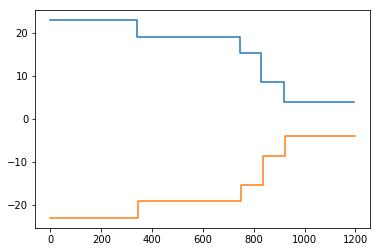

In [38]:
plt.plot(dfOneVL['x'],dfOneVL['Q']
         ,dfOneRL['x'],dfOneRL['Q'])

(2.5, 5.5)

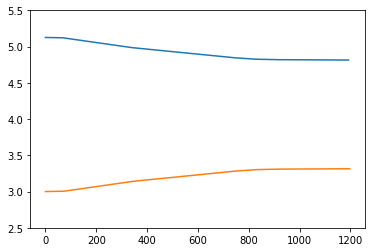

In [39]:
plt.plot(dfOneVL['x'],dfOneVL['P']
         ,dfOneRL['x'],dfOneRL['P'])
plt.ylim((2.5, 5.5))   

(2.5, 5.5)

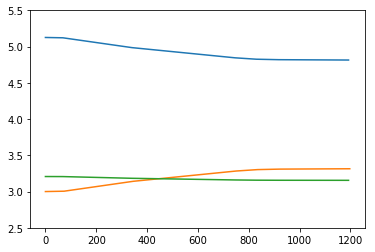

In [40]:
# SIR 3S MIN-Ergebnis lesen
xm.MxAdd(mx=mx,aggReq='TMIN')
vAGSN=xm.dataFrames['vAGSN']
dfOneVLTMIN=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]

plt.plot(dfOneVL['x'],dfOneVL['P']
         ,dfOneRL['x'],dfOneRL['P']
         ,dfOneVL['x'],dfOneVLTMIN['P']         
        )
plt.ylim((2.5, 5.5))   

## Store in H5

In [41]:
xm.ToH5()
mx.ToH5()
# next read will be faster because H5 is read instead of XML / MX if H5 is newer than XML / MX

In [42]:
xm=Xm.Xm(xmlFile=xmlFile)

In [43]:
mx=Mx.Mx(mx1File=mx1File)

In [44]:
#xm?

In [45]:
#mx?

# Rm Plot Beispiele

In [46]:
rm=Rm.Rm(xm=xm,mx=mx)

## Bsp1: Prozentdarstellung - keine Klassen

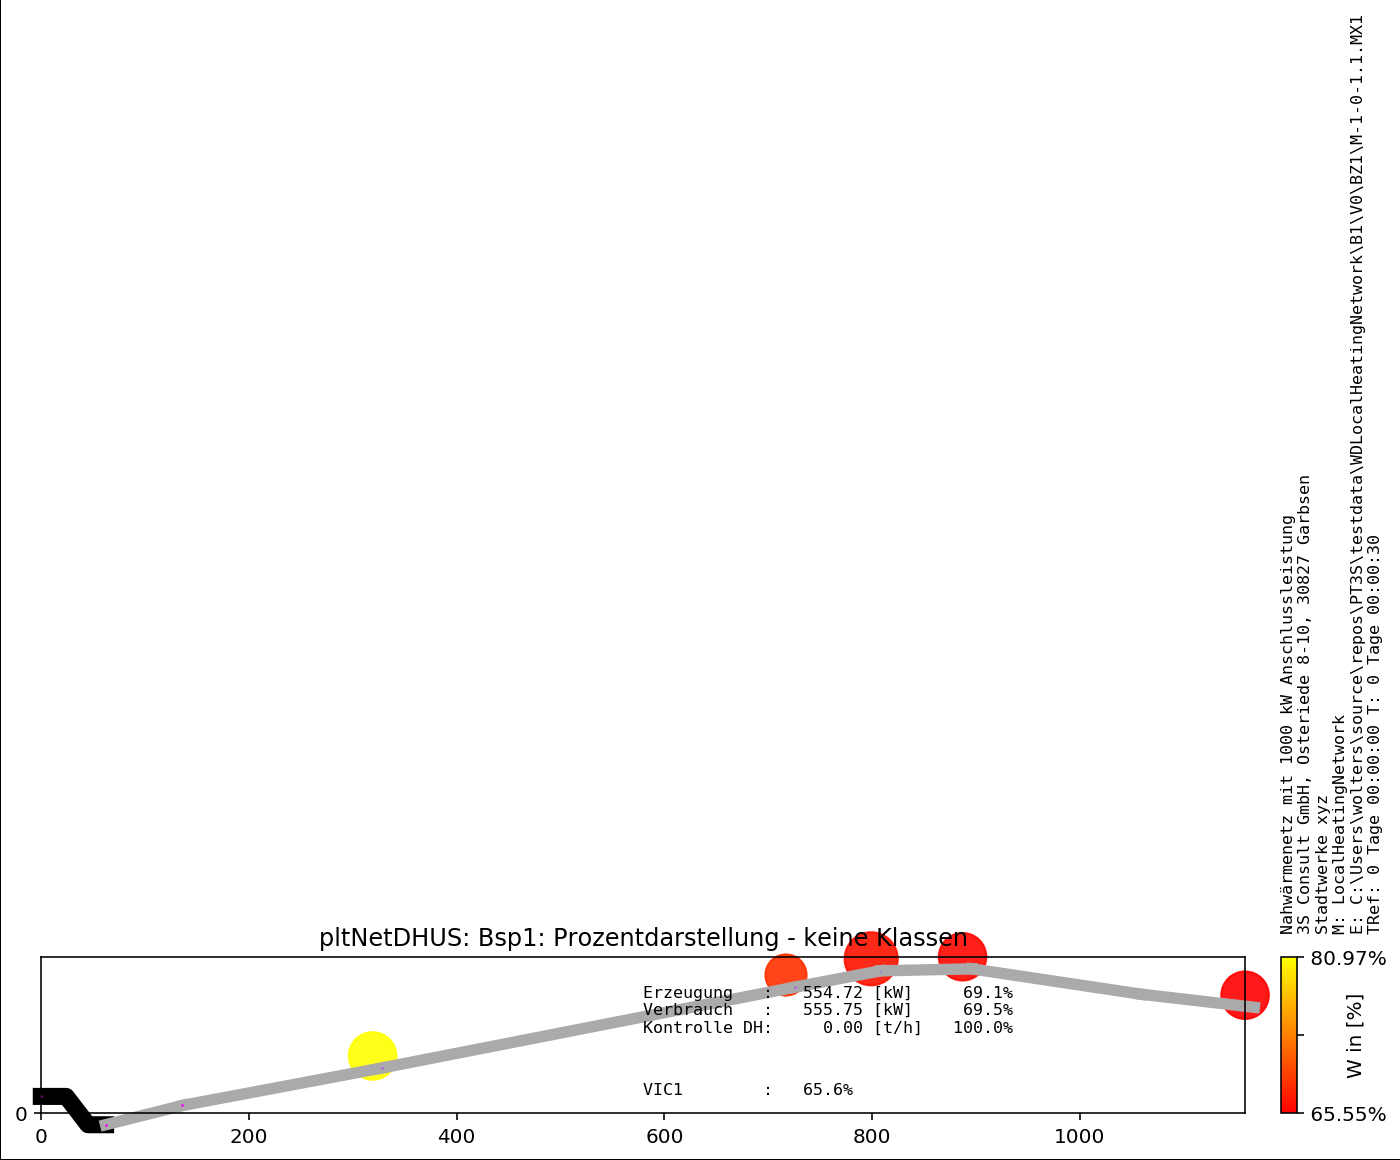

In [47]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
    
                 ,pVICsDf=pd.DataFrame({'Kundenname': ['VIC1'],'Knotenname': ['V-K007']})
    
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

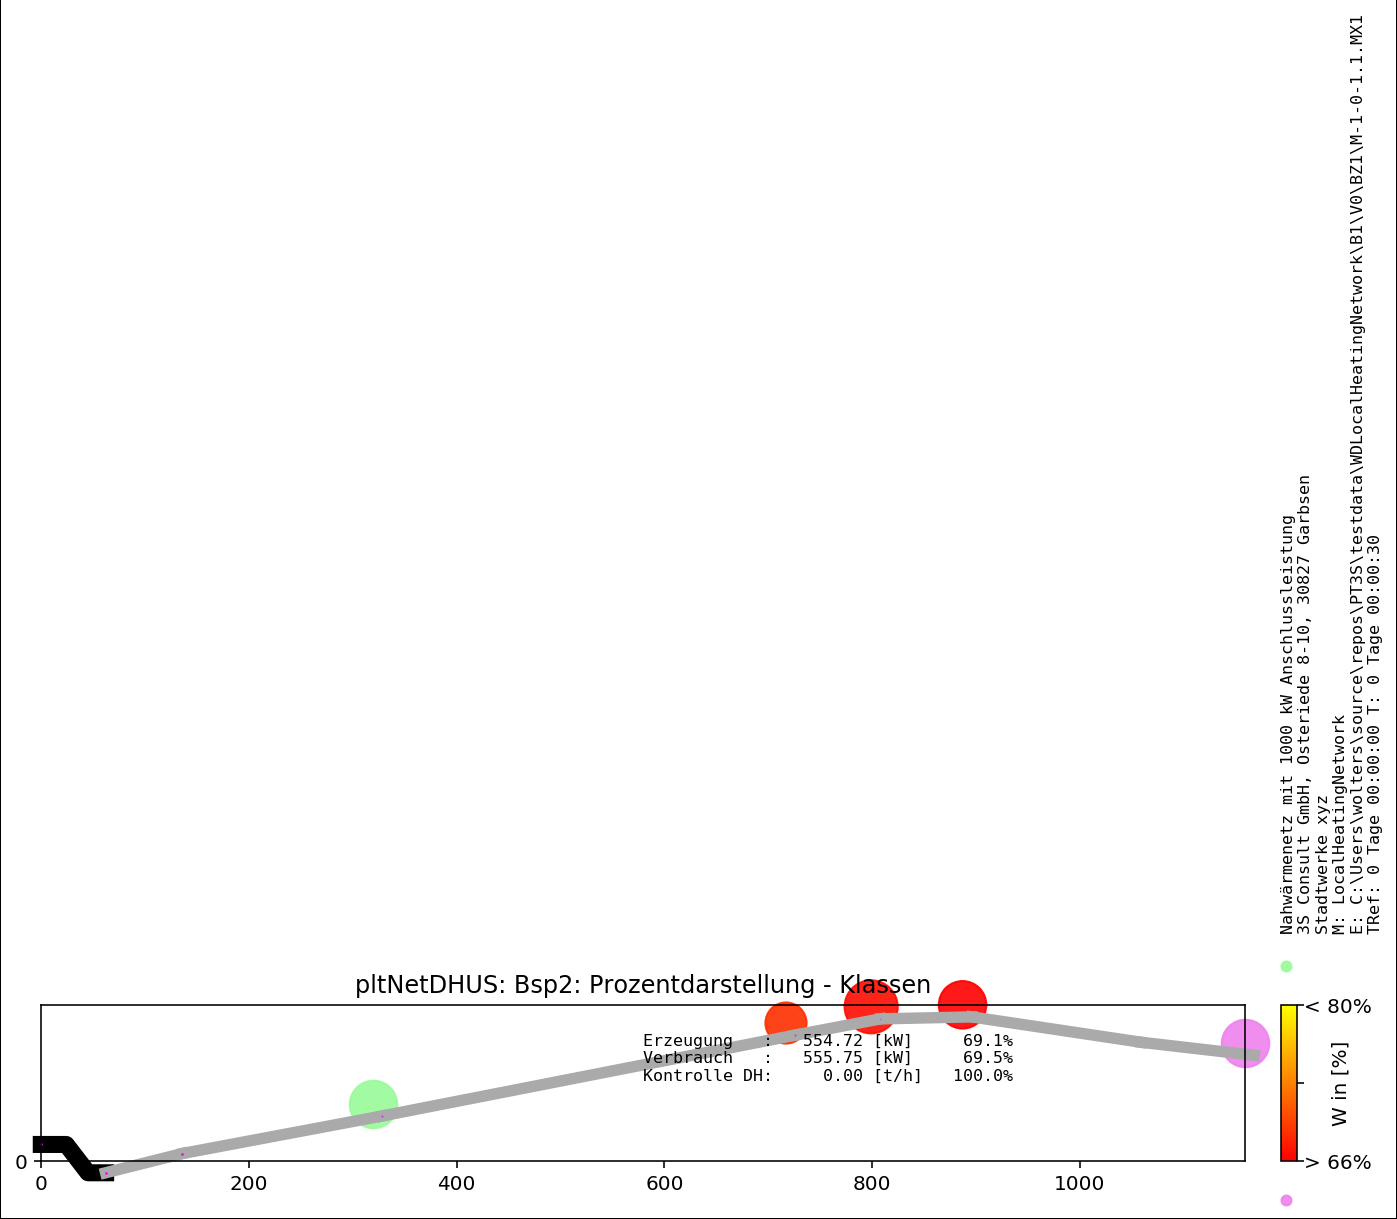

In [48]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

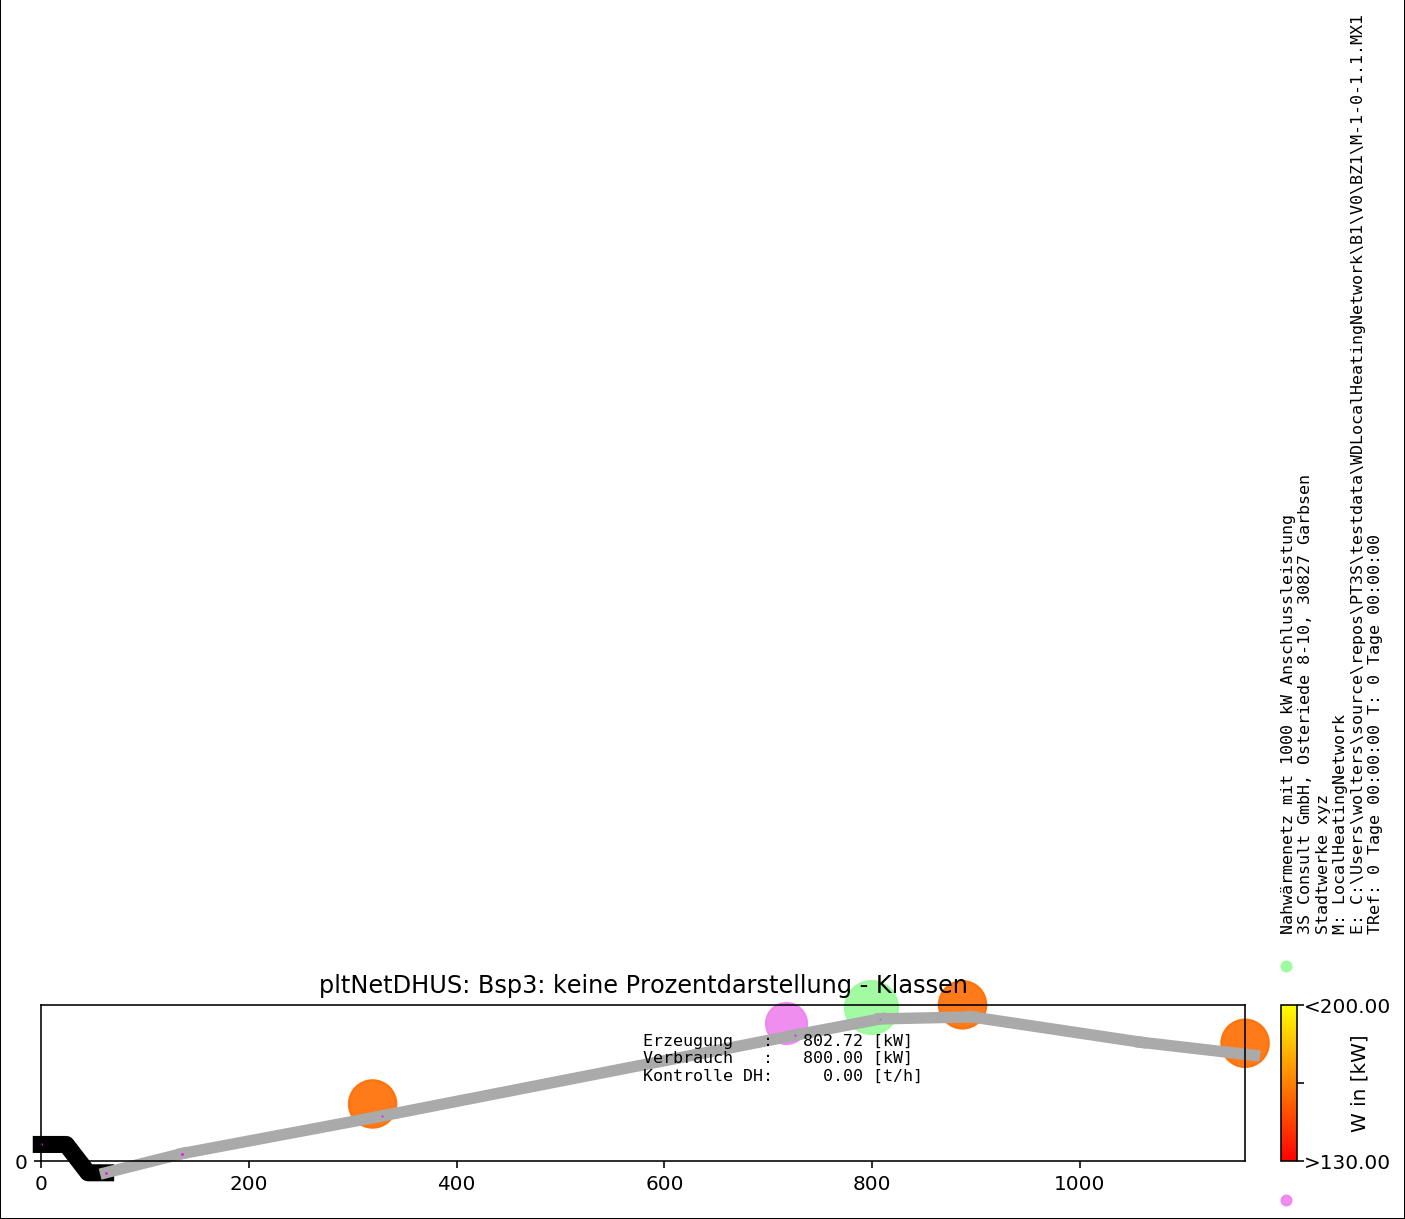

In [49]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

# NetworkX und SciPy Beispiele

In [50]:
G=nx.from_pandas_edgelist(xm.dataFrames['vVBEL'], source='NAME_i', target='NAME_k', edge_attr=True,create_using=nx.MultiGraph())

In [51]:
for e, datadict in G.edges.items():
    print(e)
    print(datadict)

('R3', 'V-1', 0)
{'BESCHREIBUNG': 'BHKW - Modul - 1000 kW therm.', 'IDREFERENZ': '-1', 'tk': '5638756766880678918', 'NAME_i': 'R3', 'CONT_i': 'BHKW', 'CONT_VKNO_i': nan, 'Z_i': '20', 'pk_i': '5219230031772497417', 'NAME_k': 'V-1', 'CONT_k': 'BHKW', 'CONT_VKNO_k': nan, 'Z_k': '20', 'pk_k': '5049461676240771430', 'LAYR': ['Vorlauf'], 'L': 0, 'D': '80', 'mx2Idx': 0, 'KNOT~*~*~*~P_i': 3.234365463256836, 'KNOT~*~*~*~HMAX_INST_i': 4.291590690612793, 'KNOT~*~*~*~H_i': 2.234365463256836, 'KNOT~*~*~*~T_i': 60.0, 'KNOT~*~*~*~PDAMPF_i': 0.19919998943805695, 'KNOT~*~*~*~HMIN_INST_i': 2.234365463256836, 'KNOT~*~*~*~PMIN_INST_i': 3.234365463256836, 'KNOT~*~*~*~RHO_i': 983.7000122070312, 'KNOT~*~*~*~PMAX_INST_i': 5.291590690612793, 'KNOT~*~*~*~WALTER_i': 0.49676936864852905, 'KNOT~*~*~*~PH_i': 2.234365463256836, 'KNOT~*~*~*~IAKTIV_i': 0.0, 'KNOT~*~*~*~P_k': 3.207463264465332, 'KNOT~*~*~*~HMAX_INST_k': 4.126019477844238, 'KNOT~*~*~*~H_k': 2.207463264465332, 'KNOT~*~*~*~T_k': 90.0, 'KNOT~*~*~*~PDAMPF_k

In [52]:
for n, nbrsdict in G.adj.items():
    print("!{0:s}".format(n))
    for nox, mgdct in nbrsdict.items(): 
        print("   {0:s}".format(nox))
        for mg,edct in  mgdct.items():
            print("        {0:d}: {1:s}".format(mg,str(edct))) 

!R3
   V-1
        0: {'BESCHREIBUNG': 'BHKW - Modul - 1000 kW therm.', 'IDREFERENZ': '-1', 'tk': '5638756766880678918', 'NAME_i': 'R3', 'CONT_i': 'BHKW', 'CONT_VKNO_i': nan, 'Z_i': '20', 'pk_i': '5219230031772497417', 'NAME_k': 'V-1', 'CONT_k': 'BHKW', 'CONT_VKNO_k': nan, 'Z_k': '20', 'pk_k': '5049461676240771430', 'LAYR': ['Vorlauf'], 'L': 0, 'D': '80', 'mx2Idx': 0, 'KNOT~*~*~*~P_i': 3.234365463256836, 'KNOT~*~*~*~HMAX_INST_i': 4.291590690612793, 'KNOT~*~*~*~H_i': 2.234365463256836, 'KNOT~*~*~*~T_i': 60.0, 'KNOT~*~*~*~PDAMPF_i': 0.19919998943805695, 'KNOT~*~*~*~HMIN_INST_i': 2.234365463256836, 'KNOT~*~*~*~PMIN_INST_i': 3.234365463256836, 'KNOT~*~*~*~RHO_i': 983.7000122070312, 'KNOT~*~*~*~PMAX_INST_i': 5.291590690612793, 'KNOT~*~*~*~WALTER_i': 0.49676936864852905, 'KNOT~*~*~*~PH_i': 2.234365463256836, 'KNOT~*~*~*~IAKTIV_i': 0.0, 'KNOT~*~*~*~P_k': 3.207463264465332, 'KNOT~*~*~*~HMAX_INST_k': 4.126019477844238, 'KNOT~*~*~*~H_k': 2.207463264465332, 'KNOT~*~*~*~T_k': 90.0, 'KNOT~*~*~*~PDA

In [53]:
print(nx.dijkstra_path(G, 'V-L', 'R-L'))

['V-L', 'V-1', 'R3', 'R-1', 'R-L']


In [54]:
max([d for n,d in nx.degree(G)]) 

4

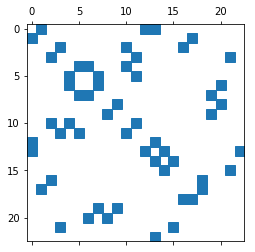

In [55]:
spmtx=nx.adjacency_matrix(G) # Return type: SciPy sparse matrix
plt.spy(spmtx)

Die Laplace-Matrix ist definiert als  L:=D-A, wobei  D die Gradmatrix und  A die Adjazenzmatrix des Graphen bezeichnet.

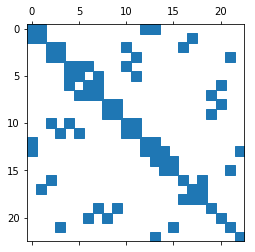

In [56]:
spmtx=nx.laplacian_matrix(G)
plt.spy(spmtx)

In [57]:
nl=[n for n in G.nodes()]

In [58]:
A=nx.to_scipy_sparse_matrix(G)

In [59]:
nlo=scipy.sparse.csgraph.reverse_cuthill_mckee(A)

In [60]:
optnl=[nl[idx] for idx in nlo]

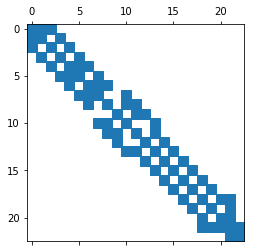

In [61]:
spmtx=nx.laplacian_matrix(G,nodelist=optnl)
plt.spy(spmtx)

## Clean Up

In [62]:
xm.delFiles()
mx.delFiles()

# Dashboard Beispiel

In [1]:
import logging
import os
logger = logging.getLogger('PT3S')  


logFileName= r"PT3S-Notebook.log"        
loglevel = logging.DEBUG
logging.basicConfig(filename=logFileName
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFileName)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

In [2]:
import Mx,Xm,Rm

In [3]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import numpy as np
import scipy
import networkx as nx
import re
from itertools import chain
import math

In [4]:
path='.'
xmlFile=os.path.join(path,'testdata\DHNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [5]:
mx=xm.MxAdd()

In [6]:
xm.ToH5()
mx.ToH5()

## TimeCurve Data

### verfügbare Szenariumzeit

In [7]:
tStartSz=mx.df.index[0]
tEndeSz=mx.df.index[-1]
tStartSz

Timestamp('2018-04-16 00:00:00+0000', tz='UTC')

In [8]:
tEndeSz

Timestamp('2018-04-16 01:00:00+0000', tz='UTC')

In [9]:
timeSpanSz=tEndeSz-tStartSz
timeSpanSz

Timedelta('0 days 01:00:00')

### ausgewählter Zeitbereich

In [10]:
tStart=tStartSz
tEnde=tEndeSz

In [11]:
tcData=mx.df.loc[tStart:tEnde,:]

In [12]:
tcData.index[0]

Timestamp('2018-04-16 00:00:00+0000', tz='UTC')

In [13]:
tcData.index[-1]

Timestamp('2018-04-16 01:00:00+0000', tz='UTC')

### Fwes W

In [14]:
mx1DfFwesW=tcData.filter(regex='^FWES').filter(regex='W$')
mx1DfFwesW=mx1DfFwesW.reindex(sorted(mx1DfFwesW.columns),axis=1)

In [15]:
mx1DfFwesW.head()

,FWES~R-A-DS-2~V-HKW1F~5237816858835684263~W,FWES~R-B-DS-2~V-HKWD~5175187672733343279~W,FWES~R-C-DS-2~V-HWSD~5293515137993465270~W
2018-04-16 00:00:00+00:00,313156.15625,164117.015625,26991.492188
2018-04-16 00:00:00.500000+00:00,313155.46875,164116.109375,26991.505859
2018-04-16 00:00:01+00:00,313154.96875,164115.437500,26991.511719
2018-04-16 00:00:01.500000+00:00,313154.46875,164116.468750,26991.527344
2018-04-16 00:00:02+00:00,313154.28125,164117.078125,26991.546875


<Figure size 417.6x295.2 with 0 Axes>

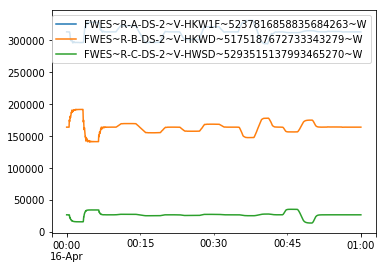

In [16]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfFwesW.plot()

In [17]:
timeSumMaxMx1DfFwesW=mx1DfFwesW.sum(axis=1).idxmax()
timeSumMaxMx1DfFwesW

Timestamp('2018-04-16 00:11:08.500000+0000', tz='UTC')

In [18]:
timeSumMinMx1DfFwesW=mx1DfFwesW.sum(axis=1).idxmin()
timeSumMinMx1DfFwesW

Timestamp('2018-04-16 00:16:07+0000', tz='UTC')

### Pump Q

In [19]:
mx1DfPumpQ=tcData.filter(regex='^PUMP').filter(regex='QM$')
mx1DfPumpQ=mx1DfPumpQ.reindex(sorted(mx1DfPumpQ.columns),axis=1)
mx1DfPumpQ.head()

,PUMP~R-A-SS~R-A-DS~5040653781471340703~QM,PUMP~R-B-SS~R-B-DS~4619979088006137294~QM,PUMP~R-C-SS~R-C-DS~5400942270878162150~QM
2018-04-16 00:00:00+00:00,3541.360107,1848.962646,304.454712
2018-04-16 00:00:00.500000+00:00,3541.352295,1848.952393,304.454865
2018-04-16 00:00:01+00:00,3541.346680,1848.944946,304.454926
2018-04-16 00:00:01.500000+00:00,3541.341309,1848.956665,304.455109
2018-04-16 00:00:02+00:00,3541.339111,1848.963501,304.455353


<Figure size 417.6x295.2 with 0 Axes>

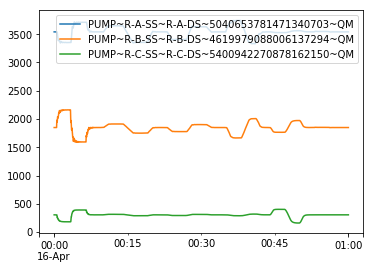

In [20]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPumpQ.plot()

### Pump Ny

In [21]:
mx1DfPumpNy=tcData.filter(regex='^PUMP').filter(regex='N$')
mx1DfPumpNy=mx1DfPumpNy.reindex(sorted(mx1DfPumpNy.columns),axis=1)

In [22]:
mx1DfPumpNy.head()

,PUMP~R-A-SS~R-A-DS~5040653781471340703~N,PUMP~R-B-SS~R-B-DS~4619979088006137294~N,PUMP~R-C-SS~R-C-DS~5400942270878162150~N
2018-04-16 00:00:00+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:00.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:02+00:00,1475.0,1373.0,1387.0


### Pump Nw

In [23]:
mx1DfPumpWCols=[col for col in mx.df.columns.tolist() 
if 
re.match(Mx.reSir3sIDcompiled,col).group('NAME1') in ['wNA','wNB','wNC']
and 
re.match(Mx.reSir3sIDcompiled,col).group('ATTRTYPE') in ['XA']
and 
re.match(Mx.reSir3sIDcompiled,col).group('OBJTYPE') in ['RSLW']
]

In [24]:
mx1DfPumpNw=tcData.filter(items=mx1DfPumpWCols)
mx1DfPumpNw=mx1DfPumpNw.reindex(sorted(mx1DfPumpNw.columns),axis=1)

In [25]:
mx1DfPumpNw.head()

,RSLW~wNA~~4991855568438544033~XA,RSLW~wNB~~4658075570394029953~XA,RSLW~wNC~~5240575308071562858~XA
2018-04-16 00:00:00+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:00.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:01.500000+00:00,1475.0,1373.0,1387.0
2018-04-16 00:00:02+00:00,1475.0,1373.0,1387.0


### Pump Nyw-Pairs

In [26]:
mx1DfPumpNywPairs=pd.concat([mx1DfPumpNy,mx1DfPumpNw],axis=1) 

In [27]:
mx1DfPumpNywPairs=mx1DfPumpNywPairs.filter(items=list(chain.from_iterable(
    [x for x in zip(mx1DfPumpNy.columns.tolist(),mx1DfPumpNw.columns.tolist())]
                                                                         )
                                                     )
                                          ) 

In [28]:
mx1DfPumpNywPairs.head()

,PUMP~R-A-SS~R-A-DS~5040653781471340703~N,RSLW~wNA~~4991855568438544033~XA,PUMP~R-B-SS~R-B-DS~4619979088006137294~N,RSLW~wNB~~4658075570394029953~XA,PUMP~R-C-SS~R-C-DS~5400942270878162150~N,RSLW~wNC~~5240575308071562858~XA
2018-04-16 00:00:00+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:00.500000+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:01+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:01.500000+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0
2018-04-16 00:00:02+00:00,1475.0,1475.0,1373.0,1373.0,1387.0,1387.0


<Figure size 417.6x295.2 with 0 Axes>

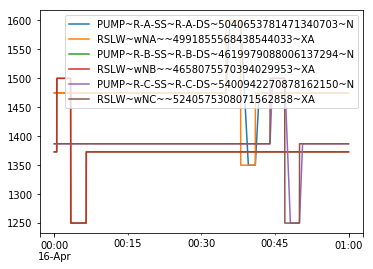

In [29]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPumpNywPairs.plot()

### Leckagen

In [30]:
mx1DfPipeLIO=tcData.filter(regex='^ROHR').filter(regex='LECKEINAUS$')
mx1DfPipeLIO=mx1DfPipeLIO.reindex(sorted(mx1DfPipeLIO.columns),axis=1)
mx1DfPipeLIO.head()

,ROHR~R-1110~R-1111~4705870204270598692~LECKEINAUS,ROHR~R-1905~R-1906~5311481409516587480~LECKEINAUS,ROHR~R-3008~R-3007~5158013150991786892~LECKEINAUS,ROHR~V-1110~V-1111~5213993202286076270~LECKEINAUS,ROHR~V-1905~V-1906~5678479042185086221~LECKEINAUS,ROHR~V-3008~V-3007~5495210784952840476~LECKEINAUS
2018-04-16 00:00:00+00:00,0,0,0,0,0,1
2018-04-16 00:00:00.500000+00:00,0,0,0,0,0,1
2018-04-16 00:00:01+00:00,0,0,0,0,0,1
2018-04-16 00:00:01.500000+00:00,0,0,0,0,0,1
2018-04-16 00:00:02+00:00,0,0,0,0,0,1


In [31]:
mx1DfPipeLQ=tcData.filter(regex='^ROHR').filter(regex='LECKMENGE$')
mx1DfPipeLQ=mx1DfPipeLQ.reindex(sorted(mx1DfPipeLQ.columns),axis=1)
mx1DfPipeLQ.head()

,ROHR~R-1110~R-1111~4705870204270598692~LECKMENGE,ROHR~R-1905~R-1906~5311481409516587480~LECKMENGE,ROHR~R-3008~R-3007~5158013150991786892~LECKMENGE,ROHR~V-1110~V-1111~5213993202286076270~LECKMENGE,ROHR~V-1905~V-1906~5678479042185086221~LECKMENGE,ROHR~V-3008~V-3007~5495210784952840476~LECKMENGE
2018-04-16 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:00.500000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:01+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:01.500000+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-16 00:00:02+00:00,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
mx1DfPipeLPairs=pd.concat([mx1DfPipeLIO,mx1DfPipeLQ],axis=1) 
mx1DfPipeLPairs=mx1DfPipeLPairs.filter(items=list(chain.from_iterable(
    [x for x in zip(mx1DfPipeLIO.columns.tolist(),mx1DfPipeLQ.columns.tolist())]
                                                                         )
                                                     )
                                          ) 

In [33]:
mx1DfPipeLPairs.describe()

,ROHR~R-1110~R-1111~4705870204270598692~LECKEINAUS,ROHR~R-1110~R-1111~4705870204270598692~LECKMENGE,ROHR~R-1905~R-1906~5311481409516587480~LECKEINAUS,ROHR~R-1905~R-1906~5311481409516587480~LECKMENGE,ROHR~R-3008~R-3007~5158013150991786892~LECKEINAUS,ROHR~R-3008~R-3007~5158013150991786892~LECKMENGE,ROHR~V-1110~V-1111~5213993202286076270~LECKEINAUS,ROHR~V-1110~V-1111~5213993202286076270~LECKMENGE,ROHR~V-1905~V-1906~5678479042185086221~LECKEINAUS,ROHR~V-1905~V-1906~5678479042185086221~LECKMENGE,ROHR~V-3008~V-3007~5495210784952840476~LECKEINAUS,ROHR~V-3008~V-3007~5495210784952840476~LECKMENGE
count,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000,7201.0,7201.000000
mean,0.0,0.499931,0.0,0.499931,0.0,0.499931,0.0,0.499931,0.0,0.499931,1.0,0.499931
std,0.0,2.179457,0.0,2.179457,0.0,2.179457,0.0,2.179457,0.0,2.179457,0.0,2.179457
min,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
25%,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
50%,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
75%,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.000000
max,0.0,10.000000,0.0,10.000000,0.0,10.000000,0.0,10.000000,0.0,10.000000,1.0,10.000000


In [34]:
# effektive Leckmengen als ~LEAK = ~LECKEINAUS * ~LECKMENGE
colList=mx1DfPipeLPairs.columns.tolist()
for idx in range(0,len(colList),2):

    col=colList[idx]
    mo=re.match(Mx.reSir3sIDcompiled,col)
    colNew=mo.group('OBJTYPE')
    colNew=colNew+Mx.reSir3sIDSep+str(mo.group('NAME1'))
    colNew=colNew+Mx.reSir3sIDSep+mo.group('NAME2')
    colNew=colNew+Mx.reSir3sIDSep+mo.group('OBJTYPE_PK')
    colNew=colNew+Mx.reSir3sIDSep+'LEAK'
    
    mx1DfPipeLPairs[colNew]=mx1DfPipeLPairs.apply(lambda row: row[idx] * row[idx+1] , axis=1)

In [35]:
mx1DfPipeLeaks=mx1DfPipeLPairs.filter(regex='LEAK$')
mx1DfPipeLeaks.describe()

,ROHR~R-1110~R-1111~4705870204270598692~LEAK,ROHR~R-1905~R-1906~5311481409516587480~LEAK,ROHR~R-3008~R-3007~5158013150991786892~LEAK,ROHR~V-1110~V-1111~5213993202286076270~LEAK,ROHR~V-1905~V-1906~5678479042185086221~LEAK,ROHR~V-3008~V-3007~5495210784952840476~LEAK
count,7201.0,7201.0,7201.0,7201.0,7201.0,7201.000000
mean,0.0,0.0,0.0,0.0,0.0,0.499931
std,0.0,0.0,0.0,0.0,0.0,2.179457
min,0.0,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.000000
75%,0.0,0.0,0.0,0.0,0.0,0.000000
max,0.0,0.0,0.0,0.0,0.0,10.000000


In [36]:
s=mx1DfPipeLeaks.max()
s=s[s>0]
s.index.tolist()
mx1DfPipeLeaks=mx1DfPipeLeaks.filter(items=s.index.tolist())
mx1DfPipeLeaks.head()

,ROHR~V-3008~V-3007~5495210784952840476~LEAK
2018-04-16 00:00:00+00:00,0.0
2018-04-16 00:00:00.500000+00:00,0.0
2018-04-16 00:00:01+00:00,0.0
2018-04-16 00:00:01.500000+00:00,0.0
2018-04-16 00:00:02+00:00,0.0


<Figure size 417.6x295.2 with 0 Axes>

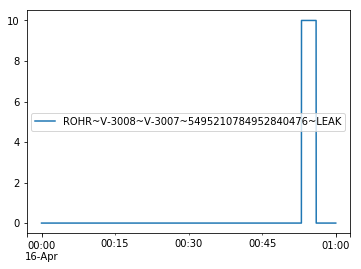

In [37]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPipeLeaks.plot()

### DH

#### Rename (um die Kanäle ohne die ID auswählen zu können)

In [38]:
colDct={}
for col in tcData.columns.tolist():
    mo=re.match(Mx.reSir3sIDcompiled,col)
    colNew=mo.group('OBJTYPE')
    colNew=colNew+Mx.reSir3sIDSep+str(mo.group('NAME1'))
    colNew=colNew+Mx.reSir3sIDSep+mo.group('NAME2')
    #colNew=colNew+Mx.reSir3sIDSep+mo.group('OBJTYPE_PK')
    colNew=colNew+Mx.reSir3sIDSep+mo.group('ATTRTYPE')
    colDct[col]=colNew
df=tcData.rename(columns=colDct)

In [39]:
mx1DfDH=pd.concat([df['RSLW~wDH_RD_A~~XA']
                  ,df['RMES~yDH_pRL_A~~XA'] 
                  ,df['RSLW~wDH_MD_A~~XA']
                  ,df['RADD~yDH_pMD_A~~XA']                    
                  ]
                  , axis=1)

In [40]:
mx1DfDH.head()

,RSLW~wDH_RD_A~~XA,RMES~yDH_pRL_A~~XA,RSLW~wDH_MD_A~~XA,RADD~yDH_pMD_A~~XA
2018-04-16 00:00:00+00:00,4.2,4.2,6.7,6.674987
2018-04-16 00:00:00.500000+00:00,4.2,4.2,6.7,6.674994
2018-04-16 00:00:01+00:00,4.2,4.2,6.7,6.674996
2018-04-16 00:00:01.500000+00:00,4.2,4.2,6.7,6.675000
2018-04-16 00:00:02+00:00,4.2,4.2,6.7,6.675003


<Figure size 417.6x295.2 with 0 Axes>

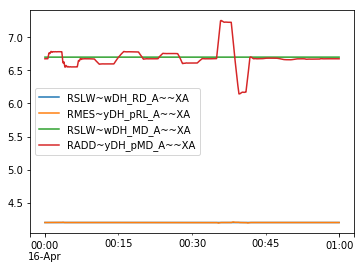

In [41]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfDH.plot()

In [42]:
mx1DfDHQ=pd.concat([df['RMES~QDHGes~~XA'] 
                  ,df['ALLG~~~LINEPACKRATE']                                  
                  ]
                  , axis=1)

In [43]:
mx1DfDHQ.head()

,RMES~QDHGes~~XA,ALLG~~~LINEPACKRATE
2018-04-16 00:00:00+00:00,0.000015,0.000000
2018-04-16 00:00:00.500000+00:00,-0.034913,-0.034886
2018-04-16 00:00:01+00:00,-0.058737,-0.059210
2018-04-16 00:00:01.500000+00:00,-0.075768,-0.076183
2018-04-16 00:00:02+00:00,-0.086045,-0.086424


In [44]:
mx1DfDHV=pd.concat([df['ALLG~~~LINEPACKGEOM']                                  
                  ]
                  , axis=1)
mx1DfDHV=mx1DfDHV-mx1DfDHV['ALLG~~~LINEPACKGEOM'][0]
mx1DfDHV.describe()

,ALLG~~~LINEPACKGEOM
count,7201.000000
mean,0.012917
std,0.224933
min,-0.800781
25%,-0.020508
50%,0.000000
75%,0.053711
max,0.848633


In [45]:
mx1DfDHV.shape

(7201, 1)

## für Darstellungen, die mit 1 Zeit bzw. mit Aggregaten 1 Zeitraums arbeiten:

Start, Ende, Min, Max

In [46]:
def mxAdd(xm,mx,timeReq=None,aggReq=None,timeReq2nd=None):
    xm.MxAdd(mx=mx,timeReq=timeReq,aggReq=aggReq,timeReq2nd=timeReq2nd)
    vAGSN=xm.dataFrames['vAGSN']
    vKNOT=xm.dataFrames['vKNOT']
    vROHR=xm.dataFrames['vROHR']
    vFWVB=xm.dataFrames['vFWVB']
    vVBEL=xm.dataFrames['vVBEL']
    
    vAGSN=xm.dataFrames['vAGSN']
    vAGSN['PH']=vAGSN.apply(lambda row: row.P*math.pow(10.,5.)/(row.RHO*9.81),axis=1)
    vAGSN['PH']=vAGSN['PH']+vAGSN['Z'].astype('float64')
    zBzg=30.
    vAGSN['bBzg']=vAGSN.apply(lambda row: row.RHO*9.81/math.pow(10.,5.),axis=1)
    vAGSN['zBzg']=           (vAGSN['Z'].astype('float64')-zBzg)*vAGSN['bBzg']
    vAGSN['zBzg0']=          (vAGSN['Z'].astype('float64')-0   )*vAGSN['bBzg']
    vAGSN['zBzgMin']=        (vAGSN['Z'].astype('float64')-vAGSN['Z'].astype('float64').min())*vAGSN['bBzg']
    vAGSN['bBzg']=vAGSN['P']+vAGSN['zBzg']
    
    hpSL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
    hpRL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==2)]
    
    return vAGSN,vKNOT,vROHR,vFWVB,vVBEL,hpSL,hpRL

In [47]:
vAGSN_TStart,vKNOT_TStart,vROHR_TStart,vFWVB_TStart,vVBEL_TStart,hpSL_Start,hpRL_Start=mxAdd(xm,mx,timeReq=mx.df.index[0])
vAGSN_TEnde,vKNOT_TEnde,vROHR_TEnde,vFWVB_TEnde,vVBEL_TEnde,hpSL_Ende,hpRL_Ende=mxAdd(xm,mx,timeReq=mx.df.index[-1])
vAGSN_SMin,vKNOT_SMin,vROHR_SMin,vFWVB_SMin,vVBEL_SMin,hpSL_SMin,hpRL_SMin=mxAdd(xm,mx,aggReq='TMIN')
vAGSN_SMax,vKNOT_SMax,vROHR_SMax,vFWVB_SMax,vVBEL_SMax,hpSL_SMax,hpRL_SMax=mxAdd(xm,mx,aggReq='TMAX')

## Farben für Längsschnitte

In [49]:
# bar
hpCSL='red'
hpCRL='blue'
# bBzg
hpCSL2='lightcoral'
hpCRL2='cornflowerblue'
hpZ='black'
# Q
hpCSL3='salmon'
hpCRL3='lightsteelblue'
# bar Min/Max
hpCSLMax='mediumvioletred'
hpCSLMin='palevioletred'
hpCRLMax='darkcyan'
hpCRLMin='aqua'

## Farben für Zeitkurven

### konstruierte Farbtöne

10


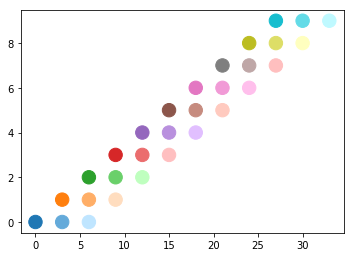

In [50]:
nCat=10
nCatSub=3 # 3 oder 5 Töne auch möglich
print(plt.get_cmap("tab10").N) # hat 10 Farben
cm = Rm.pltMakeCategoricalCmap(nCat, nCatSub, cmap="tab10")
colorsY=np.ones(nCat*nCatSub) #1
colorsX=np.ones(nCat*nCatSub) #1
for idxC in range(nCat):
    for idxCatSub in range (nCatSub):
        colorsY[idxC*nCatSub+idxCatSub]=idxC
        colorsX[idxC*nCatSub+idxCatSub]=idxC*nCatSub+idxCatSub*3
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
plt.scatter(colorsX,colorsY, c=np.arange(nCat*nCatSub), s=180, cmap=cm)

### Standard-Farbtöne

20


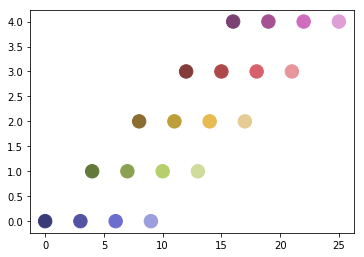

In [51]:
nCat=5
nCatSub=4
print(plt.get_cmap("tab20b").N) # hat 5*4=20 Farben
colorsY=np.ones(nCat*nCatSub) #1
colorsX=np.ones(nCat*nCatSub) #1
for idxC in range(nCat):
    for idxCatSub in range (nCatSub):
        colorsY[idxC*nCatSub+idxCatSub]=idxC
        colorsX[idxC*nCatSub+idxCatSub]=idxC*nCatSub+idxCatSub*3
plt.close()
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()        
plt.scatter(colorsX,colorsY, c=np.arange(nCat*nCatSub), s=180, cmap="tab20b")

In [52]:
# Linienattribute für Paare von Linien
lwThick=mpl.rcParams['lines.linewidth']*2 # zuerst gezeichnete Linie (hell)
lsThin='--' # danach gezeichnete Linie (dunkel)

### Festlegung der Farben

In [53]:
# fuer A,B,C: Auswahl aus konstruierten Tönen
ntcCat=10
ntcCatSub=3 
tcCm=Rm.pltMakeCategoricalCmap(ntcCat, ntcCatSub, cmap="tab10")
catA=0 # blau
catB=1 # orange
catC=2 # grün
catFromIdx={}
catFromIdx[0]=catA
catFromIdx[1]=catB
catFromIdx[2]=catC

# DH: RD,MD,VD: 
tcC_SL=plt.get_cmap("tab20b").colors[3*4+2] 
tcC_RL=plt.get_cmap("tab20b").colors[0*4+2] 
tcC_ML=plt.get_cmap("tab20b").colors[4*4+2] 

tcC_SLl=plt.get_cmap("tab20b").colors[3*4+3] 
tcC_RLl=plt.get_cmap("tab20b").colors[0*4+3] 
tcC_MLl=plt.get_cmap("tab20b").colors[4*4+3]

# DH: RD,MD-Paare: Sequenzen
tcC_XL=[tcC_RLl,tcC_RL,tcC_MLl,tcC_ML]
tcLs_XL=[mpl.rcParams['lines.linestyle'],lsThin,mpl.rcParams['lines.linestyle'],lsThin]
tcLw_XL=[lwThick,mpl.rcParams['lines.linewidth'],lwThick,mpl.rcParams['lines.linewidth']]

# DH: Q,Linepackrate:
tcC_QDH=plt.get_cmap("tab20b").colors[2*4+0] 
tcC_QLPRate=plt.get_cmap("tab20b").colors[2*4+3] 

# DH: Q,Linepackrate-Paar: Sequenz
tcC_DH=[tcC_QDH,tcC_QLPRate]
tcLs_DH=[mpl.rcParams['lines.linestyle'],lsThin]
tcLw_DH=[lwThick,mpl.rcParams['lines.linewidth']]

# DH: V
tcC_VDH=plt.get_cmap("tab20b").colors[1*4+2] 

## Plot

In [54]:
# 2 Zeiten auswählen
time1=timeSumMaxMx1DfFwesW
time2=timeSumMinMx1DfFwesW

In [55]:
# Ergebnisse für die 2 Zeiten holen
vAGSN_T1,vKNOT_T1,vROHR_T1,vFWVB_T1,vVBEL_T1,hpSL_T1,hpRL_T1=mxAdd(xm,mx,timeReq=time1)
vAGSN_T2,vKNOT_T2,vROHR_T2,vFWVB_T2,vVBEL_T2,hpSL_T2,hpRL_T2=mxAdd(xm,mx,timeReq=time2)

In [62]:
# Ref/Cmp zuordnen
timeRef=time1
timeCmp=time2

hpSLRef=hpSL_T1
hpRLRef=hpRL_T1

hpSLCmp=hpSL_T2
hpRLCmp=hpRL_T2

C:\Program Files (x86)\Microsoft Visual Studio\Shared\Anaconda3_64\lib\site-packages\matplotlib\gridspec.py:314: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


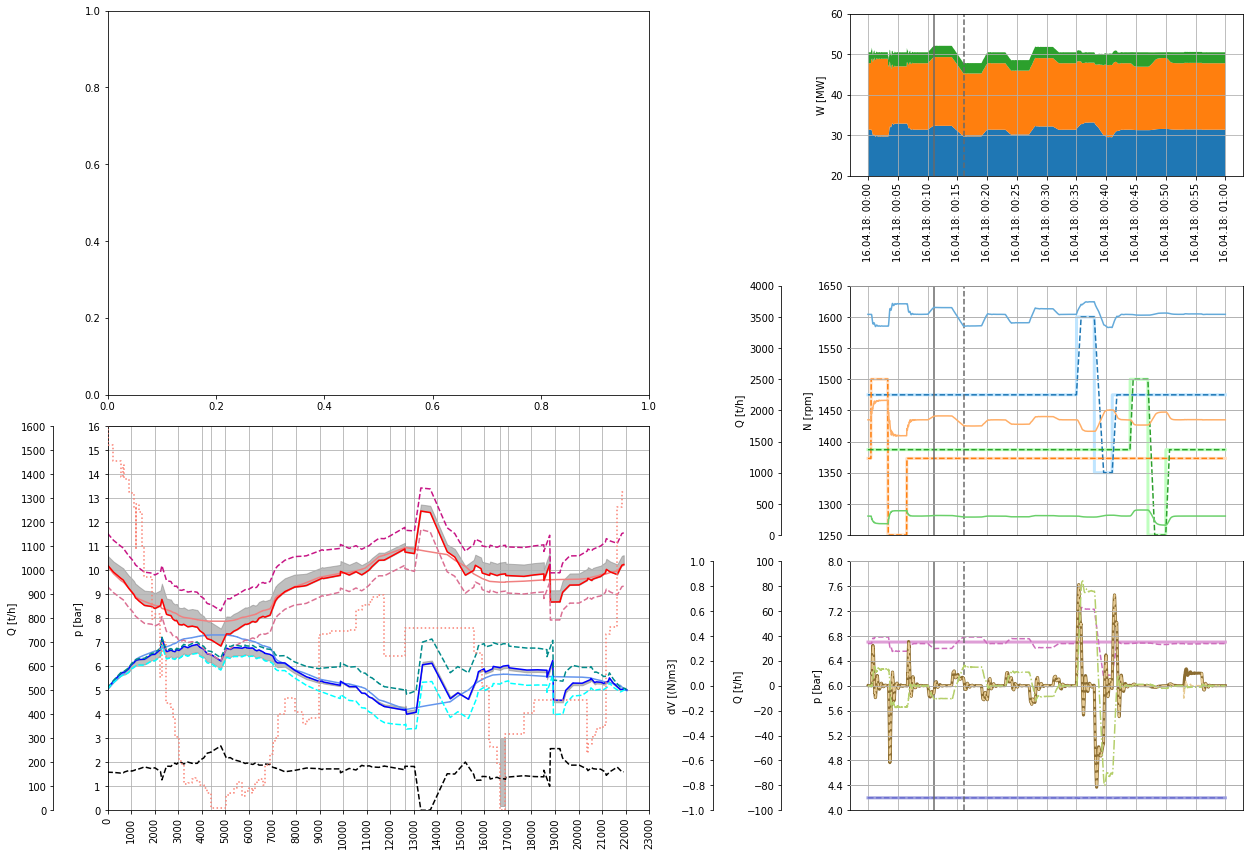

In [64]:
plt.close()

size_DINA3quer=(16.5, 11.7) 
plt.rc('figure',figsize=size_DINA3quer) 
plt.rc('figure',dpi=72)
plt.rc('savefig',dpi=72*2)
fig=plt.figure()

# .............................................................
# Paramtrierung
# .............................................................
# links: 1 NFD und 1 NDD
# .............................................................
# links nimmt die ganz linke Hälfte des Dashboards ein
leftTileRight=0.5

# rechts: 3 ZKs
# .............................................................
# rechts nimmt die ganz linke Hälfte des Dashboards ein 
rightTileStart=1-leftTileRight
# allerdings wird Platz für die y-Achsen benötigt
rightTileYAxisXSpace=0.125
rightTileStart=rightTileStart+rightTileYAxisXSpace
rightTileH_pad=0.5

# x-Achse
#majLocator=mdates.MinuteLocator(interval=5)
majLocator=mdates.MinuteLocator(byminute=[0,5,10,15,20,25,30,35,40,45,50,55])
majFormatter=mdates.DateFormatter('%d.%m.%y: %H:%M')

# .............................................................
# links: 1 NFD und 1 NDD
# .............................................................
gs1 = gridspec.GridSpec(2, 1)
axNfd = fig.add_subplot(gs1[0])
axHp = fig.add_subplot(gs1[1])
gs1.tight_layout(fig, rect=[0, 0, leftTileRight, 1])
    #rect : if rect is given, it is interpreted as a rectangle
    #(left, bottom, right, top) in the normalized figure coordinate that the whole subplots area (including labels) will fit into

    
# .............................................................
# HP
# .............................................................
    
# (negativer) Abstand der 2. y-Achse von der Zeichenfläche
yTwinedAxesPosDeltaHP=-0.100

axHp.set_ylabel('p [bar]')  
axHp.set_ylim(0,16)          
axHp.set_yticks(np.arange(0, 16.1, 1))  

axHp.plot(hpSLRef['x'],hpSLRef['bBzg'],color=hpCSL2)        
axHp.plot(hpRLRef['x'],hpRLRef['bBzg'],color=hpCRL2)   

axHp.plot(hpSLRef['x'],hpSLRef['zBzgMin'],color=hpZ,ls='--')   

axHp.plot(hpSLRef['x'],hpSLRef['P'],color=hpCSL)        
axHp.plot(hpRLRef['x'],hpRLRef['P'],color=hpCRL)   


hpSLRef = hpSLRef.apply(pd.to_numeric, errors='ignore')
hpSLCmp = hpSLCmp.apply(pd.to_numeric, errors='ignore')
axHp.fill_between(hpSLRef['x'], hpSLRef['P'], hpSLCmp['P'], color='grey', alpha='0.5')
hpRLRef = hpRLRef.apply(pd.to_numeric, errors='ignore')
hpRLCmp = hpRLCmp.apply(pd.to_numeric, errors='ignore')
axHp.fill_between(hpRLRef['x'], hpRLRef['P'], hpRLCmp['P'], color='grey', alpha='0.5')

axHp.plot(hpSL_SMax['x'],hpSL_SMax['P'],color=hpCSLMax,ls='--')        
axHp.plot(hpSL_SMin['x'],hpSL_SMin['P'],color=hpCSLMin,ls='--')   

axHp.plot(hpRL_SMax['x'],hpRL_SMax['P'],color=hpCRLMax,ls='--')        
axHp.plot(hpRL_SMin['x'],hpRL_SMin['P'],color=hpCRLMin,ls='--') 



# x-Achse
ax=axHp
axHp.set_xlim(0,23000)          
axHp.set_xticks(np.arange(0, 23000.1, 1000))      
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.grid()

# 2. y-Achse
axHp_2nd = axHp.twinx()
axHp_2nd.spines["left"].set_position(("axes", yTwinedAxesPosDeltaHP)) 
Rm.pltMakePatchSpinesInvisible(axHp_2nd)
axHp_2nd.spines['left'].set_visible(True)  
axHp_2nd.yaxis.set_label_position('left')
axHp_2nd.yaxis.set_ticks_position('left')

axHp_2nd.set_ylabel('Q [t/h]')  
axHp_2nd.set_ylim(0,1600)          
axHp_2nd.set_yticks(np.arange(0, 1600.1, 100))
axHp_2nd.plot(hpSLRef['x'],hpSLRef['Q'].abs(),color=hpCSL3,ls=':')        
axHp.fill_between(hpSLRef['x'], hpSLRef['Q'], hpSLCmp['Q'], color='grey', alpha='0.5')



    
    
# .............................................................
# rechts: 3 ZKs
# .............................................................
gs2 = gridspec.GridSpec(3, 1)
axTcUp = fig.add_subplot(gs2[0])
axTcMi = fig.add_subplot(gs2[1])
axTcBo = fig.add_subplot(gs2[2])
gs2.tight_layout(fig, rect=[rightTileStart, 0, 1, 1], h_pad=rightTileH_pad)
    #pad : float
    #padding between the figure edge and the edges of subplots, as a fraction of the font-size
    #h_pad, w_pad : float
    #padding (height/width) between edges of adjacent subplots

# (negativer) Abstand der 2. y-Achse von der Zeichenfläche
yTwinedAxesPosDelta=-0.175

# .............................................................
# oberste ZK
# .............................................................
axTcUp.stackplot(mx1DfFwesW.index.values #x
                 ,np.row_stack([mx1DfFwesW[col].values for col in mx1DfFwesW.columns.tolist()]) #y
                 ,colors=[tcCm.colors[catA*ntcCatSub+0],tcCm.colors[catB*ntcCatSub+0],tcCm.colors[catC*ntcCatSub+0]]
                 ,labels=['A','B','C']
                )
axTcUp.set_ylabel('W [MW]') 
axTcUp.set_ylim(200000,600000)          
axTcUp.set_yticks(np.arange(200000, 600001, 100000))
axTcUp.set_yticklabels(["{0:2.0f}".format(x) for x in np.arange(20, 60.1,10)])
# x-Achse
ax=axTcUp
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.grid()
# wg. der x-Achse (nur in der obersten ZK) muss der eigentliche Zeichenbereich verkleinert werden
pos1 = ax.get_position()
pos2 = [pos1.x0, pos1.y0+0.10,  pos1.width, pos1.height * 0.65] 
ax.set_position(pos2) 

# .............................................................
# mittlere ZK
# .............................................................
axTcMi.set_ylabel('N [rpm]')   
axTcMi.set_ylim(1250,1650)          
axTcMi.set_yticks(np.arange(1250, 1651, 50))
for idx,col in enumerate(mx1DfPumpNw.columns.tolist()):
    line,=axTcMi.plot(mx1DfPumpNw.index.values,mx1DfPumpNw[col]
                      ,color=tcCm.colors[catFromIdx[idx]*ntcCatSub+ntcCatSub-1]
                      ,lw=lwThick)
for idx,col in enumerate(mx1DfPumpNy.columns.tolist()):
    line,=axTcMi.plot(mx1DfPumpNy.index.values,mx1DfPumpNy[col]
                      ,color=tcCm.colors[catFromIdx[idx]*ntcCatSub+0]
                      ,ls=lsThin)

# x-Achse
ax=axTcMi
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
# x-Achsenbeschriftung ausschalten
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False
    
# 2. y-Achse
axTcMi_2nd = axTcMi.twinx()
axTcMi_2nd.spines["left"].set_position(("axes", yTwinedAxesPosDelta)) 
Rm.pltMakePatchSpinesInvisible(axTcMi_2nd)
axTcMi_2nd.spines['left'].set_visible(True)  
axTcMi_2nd.yaxis.set_label_position('left')
axTcMi_2nd.yaxis.set_ticks_position('left')
axTcMi_2nd.set_ylabel('Q [t/h]')   
axTcMi_2nd.set_ylim(0,4000)          
axTcMi_2nd.set_yticks(np.arange(0, 4001, 500))
for idx,col in enumerate(mx1DfPumpQ.columns.tolist()):
    line,=axTcMi_2nd.plot(mx1DfPumpQ.index.values,mx1DfPumpQ[col]
                      ,color=tcCm.colors[catFromIdx[idx]*ntcCatSub+1]
                      )
# x-Achsenbeschriftung ausschalten
ax=axTcMi_2nd
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False

# .............................................................
# untere ZK
# .............................................................
axTcBo.set_ylabel('p [bar]')   
axTcBo.set_ylim(4,8)          
axTcBo.set_yticks(np.arange(4, 8.1, .4))
for idx,col in enumerate(mx1DfDH.columns.tolist()):
    line,=axTcBo.plot(mx1DfDH.index.values,mx1DfDH[col]                     
                      ,color= tcC_XL[idx]
                      ,ls=tcLs_XL[idx]
                      ,lw=tcLw_XL[idx]
                     )

    
ax=axTcBo
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
ax.set_xticklabels([])
ax.grid()
# x-Achsenbeschriftung ausschalten
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False

# 2. y-Achse
axTcBo_2nd = axTcBo.twinx()
axTcBo_2nd.spines["left"].set_position(("axes", yTwinedAxesPosDelta)) 
Rm.pltMakePatchSpinesInvisible(axTcBo_2nd)
axTcBo_2nd.spines['left'].set_visible(True)  
axTcBo_2nd.yaxis.set_label_position('left')
axTcBo_2nd.yaxis.set_ticks_position('left')
axTcBo_2nd.set_ylabel('Q [t/h]')   
axTcBo_2nd.set_ylim(-100,100)          
axTcBo_2nd.set_yticks(np.arange(-100, 101, 20))
for idx,col in enumerate(mx1DfDHQ.columns.tolist()):
    line,=axTcBo_2nd.plot(mx1DfDHQ.index.values,mx1DfDHQ[col]                     
                      ,color= tcC_DH[idx]
                      ,ls=tcLs_DH[idx]
                      ,lw=tcLw_DH[idx]
                     )
# x-Achsenbeschriftung ausschalten
ax=axTcBo_2nd
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False

# 3. y-Achse
axTcBo_3rd = axTcBo.twinx()
axTcBo_3rd.spines["left"].set_position(("axes", yTwinedAxesPosDelta*2)) 
Rm.pltMakePatchSpinesInvisible(axTcBo_3rd)
axTcBo_3rd.spines['left'].set_visible(True)  
axTcBo_3rd.yaxis.set_label_position('left')
axTcBo_3rd.yaxis.set_ticks_position('left')
axTcBo_3rd.set_ylabel('dV [(N)m3]')  
axTcBo_3rd.set_ylim(-1,1)          
axTcBo_3rd.set_yticks(np.arange(-1, 1.1, .2))
line,=axTcBo_3rd.plot(mx1DfDHV.index.values,mx1DfDHV['ALLG~~~LINEPACKGEOM']                     
                      ,color= tcC_VDH
                      ,ls='-.'            
                     )
# x-Achsenbeschriftung ausschalten
ax=axTcBo_3rd
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False


    
# Zeitcursor für 2 Zeiten in allen ZKs darstellen
axLst=[axTcUp,axTcMi,axTcBo]
for ax in axLst:
    vLinePlotted=ax.axvline(x=timeRef, ymin=0, ymax=1
                              ,label='Zeit 1'
                              ,color='dimgrey'
                           #   ,linestyle=linestyle
                           #   ,linewidth=linewidth
                           )     
    vLinePlotted=ax.axvline(x=timeCmp, ymin=0, ymax=1
                              ,label='Zeit 2'
                              ,color='dimgrey'
                              ,linestyle='--'
                           #   ,linewidth=linewidth
                           )     

# Deploy

python setup.py clean sdist bdist_wheel 

pip install twine

twine upload dist/*

# Develop

In [63]:
###!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S or from PT3S import ...

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git